In [1]:
#pip install mofax
import cptac
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import umap
import mofax as mofa
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mofapy2.run.entry_point import entry_point
from process_multiomics_for_mofa import read_csv_df,filter_genes, filter_genes_ppm, scale_df, make_long, print_non_numeric_values, read_csv_df
os.environ['R_HOME'] = '/Library/Frameworks/R.framework/Resources'

In [11]:
#read rna
file_path = '/Users/sathya/work/Data/TFactivity/CPTACdatasets/CPTAC_COAD_multiOmics/CPTAC_COAD_UNC_RNAseq_BCM_RSEM_UpperQuartile_log2.cct'
index_col = 0
coad_rna = read_csv_df(file_path)
print(coad_rna.shape)
coad_rna = coad_rna.set_index('attrib_name')
coad_gene_tf_df = filter_genes(coad_rna, TF_list, axis=0)
coad_gene_tf_df.index = coad_gene_tf_df.index.astype(str) + '_rna' # rename after filtering
coad_gene_tf_df.shape

(13482, 107)


(1072, 106)

(1072, 106)


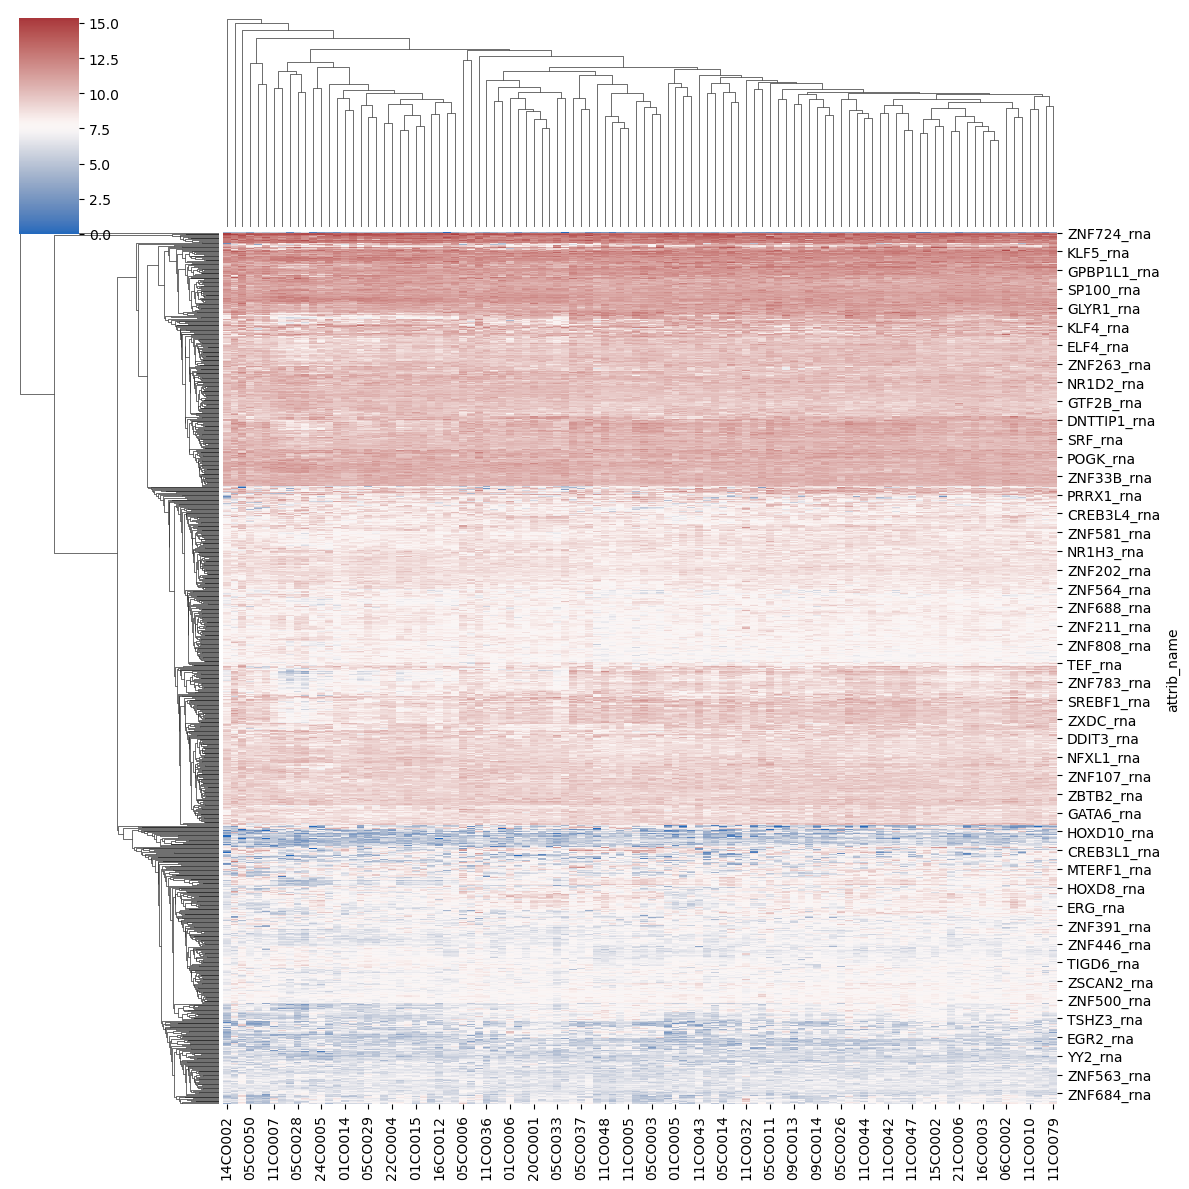

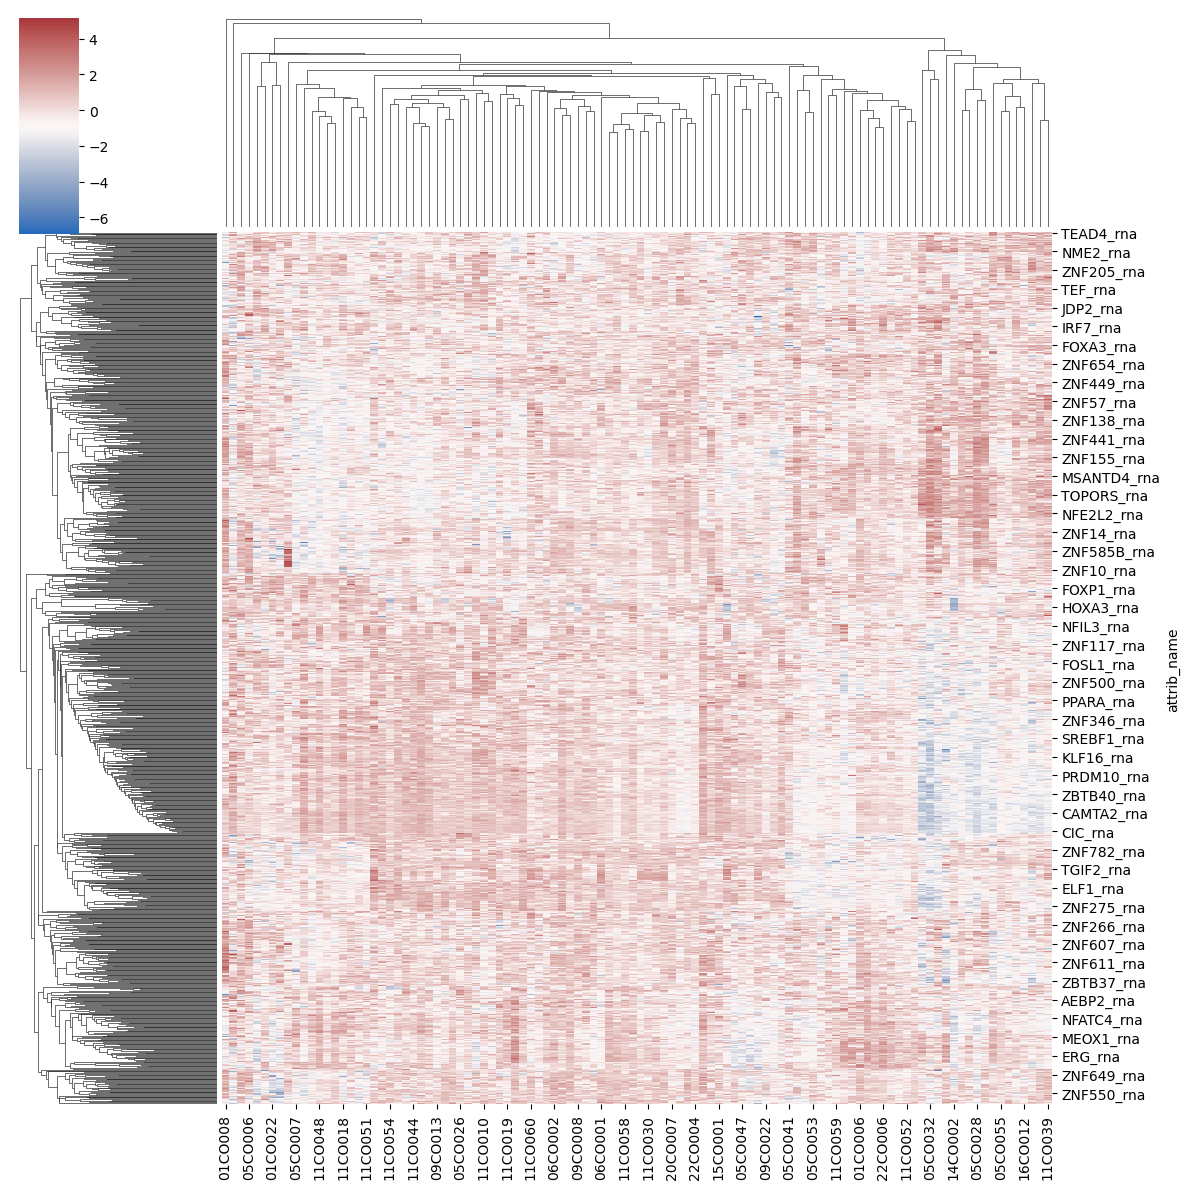

In [13]:
# Step 2: Scale and plot
df = coad_gene_tf_df
#df = coad_gene_tf_df.dropna(axis=0, thresh=int(coad_gene_tf_df.shape[1]*0.8))  # keep rows with ≥80% data
#df = df.dropna(axis=1, thresh=int(df.shape[0]*0.8))

# Step 3: (Optional) Standardize expression across samples
scaler = StandardScaler()
#coad_gene_scaled = pd.DataFrame(scaler.fit_transform(df.T).T, index=df.index, columns=df.columns)
coad_gene_scaled = scale_df(coad_gene_tf_df, axis =1)
print(coad_gene_scaled.shape)
# Step 4: Plot heatmap
sns.clustermap(df, cmap='vlag', figsize=(12, 12))
plt.show()
sns.clustermap(coad_gene_scaled, cmap='vlag', figsize=(12, 12))
plt.show()

In [17]:
#Make RNA df (long format)
coad_tf_rna = make_long(coad_gene_scaled, "RNA")
#print(coad_tf_rna.head())

In [19]:
#read and make protein df
#Read Tumor data
fp_t = 'data/CPTAC_COAD_PNNL_Proteome_Gene_Tumor_TMT_UnsharedLogRatio.cct'
index_col = 0
coad_prot_t = read_csv_df(fp_t)
#coad_prot_t.head()        # Show first 5 rows
#Filter TFs
coad_prot_t = coad_prot_t.set_index('attrib_name')
coad_prot_t_tf_df = filter_genes(coad_prot_t, TF_list, axis=0)
coad_prot_t_tf_df.index = coad_prot_t_tf_df.index.astype(str) + '_protein'
#print(coad_prot_t_tf_df.shape)

#Read Normal data
fp_n = 'data/CPTAC_COAD_PNNL_Proteome_Gene_Normal_TMT_UnsharedLogRatio.cct'
index_col = 0
coad_prot_n = read_csv_df(fp_n)
#coad_prot_n.head()        # Show first 5 rows
#coad_rna.columns       # List column names
#coad_rna.shape         # (rows, columns)
#Filter TFs
coad_prot_n = coad_prot_n.set_index('attrib_name')
coad_prot_n_tf_df = filter_genes(coad_prot_n, TF_list, axis=0)
coad_prot_n_tf_df.index = coad_prot_n_tf_df.index.astype(str) + '_protein' # rename after filtering
#print(coad_prot_n_tf_df.shape)

# Standardize expression a
#concatenate 
coad_tf_protein = pd.concat([coad_prot_n_tf_df, coad_prot_t_tf_df], axis=1)
coad_tf_protein_scaled = scale_df(coad_tf_protein, axis =1)
print(coad_tf_protein_scaled.head())
print(coad_tf_protein_scaled.shape)

#Make Long dfs
coad_tf_lprotein = make_long(coad_tf_protein_scaled, "protein")
print(coad_tf_protein.head())

#coad_tf_t_protein = make_long(coad_prot_t_tf_df, "protein")
#print(coad_tf_t_protein.head())


                01CO001N  01CO005N  01CO006N  01CO008N  01CO013N  01CO014N  \
attrib_name                                                                  
ADNP_protein   -0.829402 -1.013600 -1.481644 -0.291906 -0.397593 -0.557634   
AEBP1_protein   0.754645 -0.601826  0.339164 -0.895783 -0.398191 -0.325933   
AHCTF1_protein -1.155132 -0.489315 -0.146951 -0.370728 -0.646905 -0.386881   
AHR_protein     0.109706 -1.131396       NaN       NaN -0.544662  2.076857   
AKAP8_protein  -1.703865 -0.700421 -1.582695 -0.715568  0.199270 -1.378219   

                01CO015N  01CO019N  01CO022N  05CO002N  ...   20CO001  \
attrib_name                                             ...             
ADNP_protein   -1.200818 -0.829402 -0.919991 -1.218935  ...  0.238343   
AEBP1_protein  -0.324291 -0.040188 -0.902352  0.306484  ...  0.618341   
AHCTF1_protein -0.796615  0.676851 -0.074065 -0.406580  ...  1.031428   
AHR_protein          NaN -1.929124 -0.007640 -0.129612  ...       NaN   
AKAP8_protein  

In [21]:
#read and make ppm df
fpm_t = 'data/CPTAC_COAD_multiOmics/CPTAC_COAD_PNNL_Phosphoproteome_Tumor_LogRatio.cct'
index_col = 0
coad_ppm_t = read_csv_df(fpm_t)
#print(coad_ppm_t.columns)
coad_ppm_t = coad_ppm_t.set_index('attrib_name')
coad_ppm_t.index = coad_ppm_t.index.str.split('__').str[0]
coad_ppm_t["Gene"] = coad_ppm_t.index.str.split('_').str[0]
#print(coad_ppm_t.head())
coad_ppm_t_tf_df = filter_genes_ppm(coad_ppm_t, TF_list, axis=0)
coad_ppm_t_tf_df = coad_ppm_t_tf_df.dropna(axis=1, how='all')
coad_ppm_t_tf_df.index = coad_ppm_t_tf_df.index.astype(str) + '_pp'
print(coad_ppm_t_tf_df.shape)

fpm_n = 'data/CPTAC_COAD_multiOmics/CPTAC_COAD_PNNL_Phosphoproteome_Normal_logRatio.cct'
index_col = 0
coad_ppm_n = read_csv_df(fpm_n)
# Change colnames of normal samples to 
coad_ppm_n.columns = [
    col if i == 0 else f"{col}N"
    for i, col in enumerate(coad_ppm_n.columns)
]
#print(coad_ppm_n.head())
coad_ppm_n = coad_ppm_n.set_index('attrib_name')
coad_ppm_n.index = coad_ppm_n.index.str.split('__').str[0]
coad_ppm_n["Gene"] = coad_ppm_n.index.str.split('_').str[0]
#print(coad_ppm_n.head())
coad_ppm_n_tf_df = filter_genes_ppm(coad_ppm_n, TF_list, axis=0)
coad_ppm_n_tf_df = coad_ppm_n_tf_df.dropna(axis=1, how='all')
coad_ppm_n_tf_df.index = coad_ppm_n_tf_df.index.astype(str) + '_pp'
print(coad_ppm_n_tf_df.shape)

#concatenate before making long
coad_tf_ppm = pd.concat([coad_ppm_n_tf_df, coad_ppm_t_tf_df], axis =1)
coad_tf_ppm_scaled = scale_df(coad_tf_ppm, axis =1)

coad_tf_lppm = make_long(coad_tf_ppm_scaled, "ppm")
print(coad_tf_lppm.head())
#coad_tf_t_ppm = make_long(coad_ppm_t_tf_df, "ppm")
#print(coad_tf_t_ppm.head())


(2263, 97)
(2263, 100)
    attrib_name Patient_ID     Value view
0  E2F8_S102_pp   01CO001N       NaN  ppm
1  E2F8_S413_pp   01CO001N       NaN  ppm
2  E2F8_S417_pp   01CO001N       NaN  ppm
3  E2F8_S664_pp   01CO001N       NaN  ppm
4   E2F8_S71_pp   01CO001N -0.425166  ppm


In [23]:
def print_non_numeric_values(df, column):
    coerced = pd.to_numeric(df[column], errors='coerce')
    non_numeric = df.loc[coerced.isna() & df[column].notna(), column]
    print(non_numeric.unique())

# Example usage:
print_non_numeric_values(coad_tf_lppm, 'Value')
#print_non_numeric_values(coad_tf_n_ppm, 'Value')

[]


In [25]:
#Merge all omic df to single input for MOFA
#combined_coad = pd.concat([coad_tf_rna, coad_tf_t_protein, coad_tf_n_protein, coad_tf_t_ppm, coad_tf_n_ppm], axis=0)
combined_coad = pd.concat([coad_tf_rna, coad_tf_lprotein, coad_tf_lppm], axis=0)

#Drop NA
combined_coad = combined_coad.dropna(subset=['Value'])
print(combined_coad.shape)
combined_coad = combined_coad.rename(columns={'Patient_ID': 'sample', 'attrib_name': 'feature', 'Value':'value', 'View':'view'})
combined_coad['group'] = 'groupA'
combined_coad = combined_coad.drop_duplicates(subset=["group", "view", "feature", "sample"])
combined_coad = combined_coad.dropna(subset=['value'])
print(combined_coad.head())


(307249, 4)
      feature   sample     value view   group
0    ADNP_rna  01CO001 -1.014138  RNA  groupA
1   ADNP2_rna  01CO001 -0.167653  RNA  groupA
2   AEBP1_rna  01CO001 -0.824075  RNA  groupA
3   AEBP2_rna  01CO001  0.826740  RNA  groupA
4  AHCTF1_rna  01CO001  0.070202  RNA  groupA


In [27]:
## get how many features in your data
## if you only have two datasets, please skip the last row
D = [len(combined_coad[combined_coad["view"] == "RNA"]["feature"].value_counts()), 
    len(combined_coad[combined_coad["view"] == "protein"]["feature"].value_counts()),
    len(combined_coad[combined_coad["view"] == "ppm"]["feature"].value_counts())]  ## please check if you have phospho data

M = 3         # Number of views, please check your data
K = 10        # Number of factors you want to check
N = len(combined_coad[combined_coad["view"] == "ppm"]["sample"].value_counts())    # Number of samples per group
G = 1         # Number of groups, please set as 1
print(D)
print(N)

[1072, 275, 2262]
197


In [ ]:
ent = entry_point()

In [ ]:
ent.set_data_options(
    scale_groups = False, 
    scale_views = False
)
ent.set_data_df(combined_coad, likelihoods = ["gaussian", "gaussian","gaussian"])

In [ ]:
print(combined_coad['value'].apply(type).value_counts())
invalid_rows = combined_coad[pd.to_numeric(combined_coad['value'], errors='coerce').isna()]
print(invalid_rows.head())

In [ ]:
ent.set_model_options(
    factors = 10, 
    spikeslab_weights = True, 
    ard_factors = True,
    ard_weights = True
)

In [ ]:
#Set sample metadata
#ent.set_sample_metadata(metadata)
#ent.sample_metadata = metadata

In [ ]:
ent.set_train_options(
    iter = 1000, 
    convergence_mode = "medium", 
    startELBO = 1, 
    freqELBO = 1, 
    dropR2 = 0.001, 
    gpu_mode = False, 
    verbose = False, 
    seed = 42
)

In [ ]:
ent.build()
ent.run()

In [ ]:
path='/Users/sathya/work/Data/TFactivity/MultiCancer/coad/'
combined_coad_out = os.path.join(path, "Combined_coad_view.hdf5")

ent.save(outfile=combined_coad_out)

In [ ]:
coad_out = mofa.mofa_model("/Users/sathya/work/Data/TFactivity/MultiCancer/coad/Combined_coad_view.hdf5")
coad_out

In [ ]:
# Step 1: Metadata
metadata = pd.read_csv("/Users/sathya/work/Data/TFactivity/CPTACdatasets/CPTAC_COAD_multiOmics/CPTAC_COAD_clinical_selected.csv") 
#print(coad_out.get_samples())
samples = coad_out.get_samples()['sample']  # returns a dict: {group_name: [sample_ids]}
#print(samples.head())
# Step 2: UMAP embedding
factors_df = coad_out.get_factors()  # returns a dict with group names
embedding = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(factors_df)

umap_df = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])
umap_df["Patient_ID"] = samples # list of sample IDs from MOFA
merged_df = umap_df.merge(metadata, on="Patient_ID", how="left")
#print(merged_df.shape)

# Step 3: Plot
plt.figure(figsize=(8,8))
sns.scatterplot(data=merged_df, x="UMAP1", y="UMAP2", hue="tumor_stage_pathological", palette="tab10", s=100)
plt.title("UMAP of MOFA Factors Colored by Clinical Stage")
plt.tight_layout()
plt.show()

In [ ]:
coad_out.shape
print(coad_out.metadata)

In [ ]:
coad_out.get_cells().head()

In [ ]:
coad_out.metadata.shape

In [ ]:
coad_out.get_factors(factors=range(3), df=True).head()

In [ ]:
coad_out.get_r2()

In [ ]:
mofa.plot_weights_correlation(coad_out)

In [ ]:
ax = mofa.plot_weights(coad_out, n_features=5)

In [ ]:
coad_out.covariates